# Equity champions — feature importance (train-only)

All values generated from `selection_table.csv` and per-instrument artifacts. Train data only; the 30% test set is **sealed**.

In [1]:
from pathlib import Path
import math
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display

SEL_PATH = Path('outputs/model_comparison/selection_table.csv')
BASE     = Path('outputs/importance')

sel = pd.read_csv(SEL_PATH).set_index('instrument')

# ── helpers ────────────────────────────────────────────────────────────────

def load(path):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print(f'[missing] {p}')
    return pd.DataFrame()

def show(path, width=1100):
    p = Path(path)
    if p.exists():
        display(Image(str(p), width=width))
    else:
        print(f'[missing] {p}')

def get_meta(inst):
    m = load(BASE / inst / 'champion_meta.csv')
    return m.iloc[0].to_dict() if not m.empty else {}

def cluster_summary(inst):
    mem = load(BASE / inst / 'cluster_membership.csv')
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mem.empty or mda.empty:
        return pd.DataFrame()
    grp = (
        mem.groupby('cluster')
        .agg(
            n_members   =('feature', 'count'),
            dominant_pfx=('f_prefix', lambda x: x.value_counts().index[0]),
            purity      =('f_prefix', lambda x: round(x.value_counts().iloc[0] / len(x), 2)),
        )
        .reset_index()
    )
    return (
        grp.merge(mda[['cluster', 'mean_drop', 'std_drop', 'significant']],
                  on='cluster', how='left')
        .sort_values('mean_drop', ascending=False)
    )

def top_n_clusters(inst, n=3):
    """Significant clusters first (MDA desc), then non-significant (MDA desc); take n."""
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mda.empty:
        return []
    sig = mda[mda['significant']].sort_values('mean_drop', ascending=False)
    non = mda[~mda['significant']].sort_values('mean_drop', ascending=False)
    return pd.concat([sig, non])['cluster'].head(n).tolist()

def pick_score_col(wc, family):
    if family == 'logistic' and 'mean_coef_abs' in wc.columns:
        return 'mean_coef_abs', '|coef|'
    for col, lbl in [('mean_shap_mag', '|SHAP|'),
                     ('mean_perm_imp', '|Perm|'),
                     ('mean_coef_abs', '|coef|')]:
        if col in wc.columns:
            return col, lbl
    return wc.columns[2], wc.columns[2]

def print_header(inst):
    """Print section header from champion_meta; return meta dict."""
    meta    = get_meta(inst)
    mda_df  = load(BASE / inst / 'clustered_mda_full.csv')
    sig     = mda_df[mda_df['significant']] if not mda_df.empty else pd.DataFrame()
    sig_str = (
        ', '.join(f"{r['cluster']} (MDA {r['mean_drop']:.4f} \u00b1 {r['std_drop']:.4f})"
                  for _, r in sig.iterrows())
        or 'none'
    )
    family  = meta.get('family', 'tree')
    model   = meta.get('model_type', '?').upper()
    auc     = meta.get('auc_mean', float('nan'))
    std     = meta.get('auc_std',  float('nan'))
    lci     = meta.get('lower_ci', float('nan'))
    signal  = bool(meta.get('signal', False))
    grp     = meta.get('group', '?')
    n_folds = int(meta.get('n_folds', 0))
    print(f'--- {inst.upper()} | group={grp} | champion={model} | family={family} ---')
    print(f'CPCV: {n_folds} paths  AUC {auc:.4f} \u00b1 {std:.4f}  '
          f'{"SIGNAL" if signal else "NO SIGNAL"} (lower CI {lci:.4f})')
    print(f'Significant clusters: {sig_str}')
    return meta

def show_within_cluster(inst, cluster_name, family):
    wc = load(BASE / inst / f'within_cluster_{cluster_name}.csv')
    if wc.empty:
        return
    pc1 = wc['pca_pc1_var_explained'].iloc[0] if 'pca_pc1_var_explained' in wc.columns else float('nan')
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = ('>= 65% single latent' if pc1 >= 0.65 else
            ('>= 40% dominant'     if pc1 >= 0.40 else '< 40% multi-dim'))
    pc2_s   = f' PC2={pc2:.1%}' if math.isfinite(pc2) else ''
    pca_lbl = f'PC1={pc1:.1%}{pc2_s} ({tier})' if math.isfinite(pc1) else 'no PCA'
    col, col_lbl = pick_score_col(wc, family)
    display(
        wc[['feature', col, 'pc1_loading']].style
        .format({col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[col], cmap='Blues')
        .set_caption(f'{inst} | {cluster_name} — {col_lbl} ranking + PC1 loadings  ({pca_lbl})')
    )
    show(BASE / inst / f'within_cluster_{cluster_name}.png', width=950)

def show_step1(inst):
    cs = cluster_summary(inst)
    if not cs.empty:
        rng = max(cs['mean_drop'].abs().max() * 1.1, 0.005)
        display(
            cs.style
            .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
            .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-rng, vmax=rng)
            .set_caption(f'{inst} — cluster summary')
        )
    show(BASE / inst / 'dendrogram.png', width=1100)

def show_step2(inst):
    show(BASE / inst / 'clustered_mda_chart.png', width=1050)
    cc = load(BASE / inst / 'cluster_crosscheck_table.csv')
    ra = load(BASE / inst / 'rank_agreement.csv')
    if not cc.empty:
        fmt = {'mda_mean': '{:.4f}'}
        for c in ('mdi_sum', 'shap_sum', 'coef_sum', 'perm_sum'):
            if c in cc.columns:
                fmt[c] = '{:.4f}'
        rng = max(cc['mda_mean'].abs().max() * 1.2, 0.005)
        display(
            cc.style.format(fmt)
            .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-rng, vmax=rng)
            .set_caption(f'{inst} — cluster cross-check')
        )
    if not ra.empty:
        print('\nKendall \u03c4 rank agreement:')
        display(ra.style.format({'kendall_tau': '{:.2f}'}))

def show_step3(inst):
    meta   = get_meta(inst)
    family = meta.get('family', 'tree')
    top3   = top_n_clusters(inst, n=3)
    print(f'Step-3 clusters (significant first): {top3}')
    for c in top3:
        show_within_cluster(inst, c, family)

def show_step5(inst):
    meta   = get_meta(inst)
    family = meta.get('family', 'tree')
    if family == 'logistic':
        g = load(BASE / inst / 'global_coef_summary.csv')
        if not g.empty:
            sc  = 'coef_abs' if 'coef_abs' in g.columns else g.columns[1]
            fmt = {sc: '{:.4f}'}
            if 'coef_signed' in g.columns:
                fmt['coef_signed'] = '{:.4f}'
            display(
                g.head(25).style.format(fmt)
                .background_gradient(subset=[sc], cmap='Blues')
                .set_caption(f'{inst} — top 25 features by mean |coef|')
            )
        show(BASE / inst / 'global_coef_chart.png', width=1000)
    else:
        g = load(BASE / inst / 'global_shap_summary.csv')
        if not g.empty:
            sc  = 'shap_magnitude' if 'shap_magnitude' in g.columns else g.columns[1]
            fmt = {sc: '{:.4f}'}
            for c in ('shap_signed', 'mdi'):
                if c in g.columns:
                    fmt[c] = '{:.4f}'
            display(
                g.head(25).style.format(fmt)
                .background_gradient(subset=[sc], cmap='Blues')
                .set_caption(f'{inst} — top 25 features by mean |SHAP|')
            )
        show(BASE / inst / 'global_shap_chart.png', width=1000)

print('Setup complete.  Artifact root:', BASE.resolve())
print('Selection table:', len(sel), 'instruments')


Setup complete.  Artifact root: /Users/harrybrowne/Downloads/Imperial Work/SystematicTrading/stml/src/stml/new_work/outputs/importance
Selection table: 11 instruments


In [2]:
# Intro champion table — all values from selection_table + champion_meta
INSTS = ['es1s', 'nq1s', 'fesx1s']

rows = []
for inst in INSTS:
    m = get_meta(inst)
    s = sel.loc[inst]
    rows.append({
        'Instrument': inst,
        'Group'     : m.get('group',      s['best_group']),
        'Family'    : m.get('family',     s['best_model']),
        'Champion'  : m.get('model_type', s['best_model']).upper(),
        'AUC'       : f"{m.get('auc_mean', s['best_auc']):.3f}\u00b1{m.get('auc_std', 0):.3f}",
        'Lower CI'  : f"{m.get('lower_ci', s['lower_ci']):.4f}",
        'Signal'    : '\u2713' if m.get('signal', bool(s['signal'])) else '\u2717',
    })

intro_df = pd.DataFrame(rows)
display(
    intro_df.style
    .set_caption('Equity champions — source: selection_table.csv \u2192 champion_meta.csv')
    .hide(axis='index')
)

# Warn about MLP instruments (artifacts may have been computed with a different model)
for inst in INSTS:
    s = sel.loc[inst]
    m = get_meta(inst)
    if s['best_model'] == 'mlp' and m.get('model_type', '') != 'mlp':
        print(f'\u26a0\ufe0f  {inst}: selection_table champion=MLP but champion_meta shows '
              f'{m.get("model_type","?")}.  Importance artifacts may be from the runner-up model.')


Instrument,Group,Family,Champion,AUC,Lower CI,Signal
es1s,es1s,logistic,LOGISTIC,0.595±0.029,0.5668,✓
nq1s,nq1s,tree,XGB,0.570±0.033,0.5374,✓
fesx1s,fesx1s,tree,RF,0.496±0.024,0.4722,✗


---
### ES1S — Steps 1–5

In [3]:
meta = print_header('es1s')

--- ES1S | group=es1s | champion=LOGISTIC | family=logistic ---
CPCV: 15 paths  AUC 0.5953 ± 0.0285  SIGNAL (lower CI 0.5668)
Significant clusters: C10_f1 (MDA 0.0515 ± 0.0376), C2_f2 (MDA 0.0298 ± 0.0256), C8_f11_lowfreq_macro (MDA 0.0279 ± 0.0197)


#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
0,C10_f1,14,f1_,79%,0.0515,0.0376,True
6,C2_f2,16,f2_,44%,0.0298,0.0256,True
12,C8_f11_lowfreq_macro,3,f11_,100%,0.0279,0.0197,True
2,C12_f11,3,f11_,67%,0.0119,0.0151,False
5,C1_f11,7,f11_,71%,0.0068,0.0083,False
15,F5_signal,5,f5_,100%,0.0060,0.0189,False
9,C5_f7,3,f7_,100%,0.0044,0.0124,False
1,C11_f11,6,f11_,67%,0.0011,0.0031,False
3,C13_f6,6,f6_,33%,0.0010,0.0091,False
14,F4_latent,4,f4_,100%,-0.0007,0.0021,False


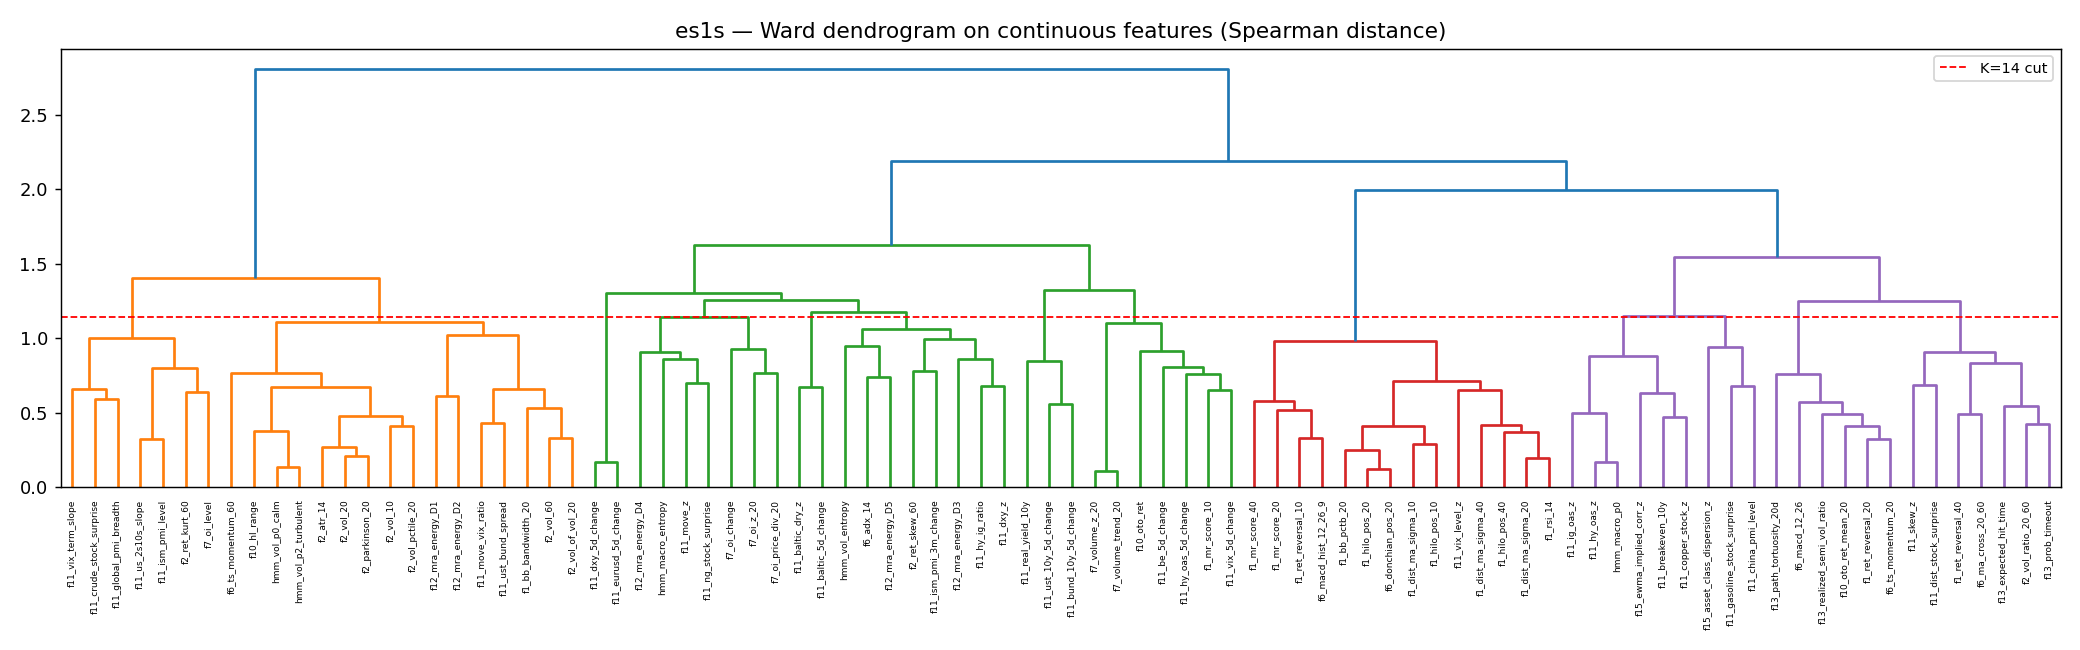

In [4]:
show_step1('es1s')

#### Step 2 · Cluster-level importance

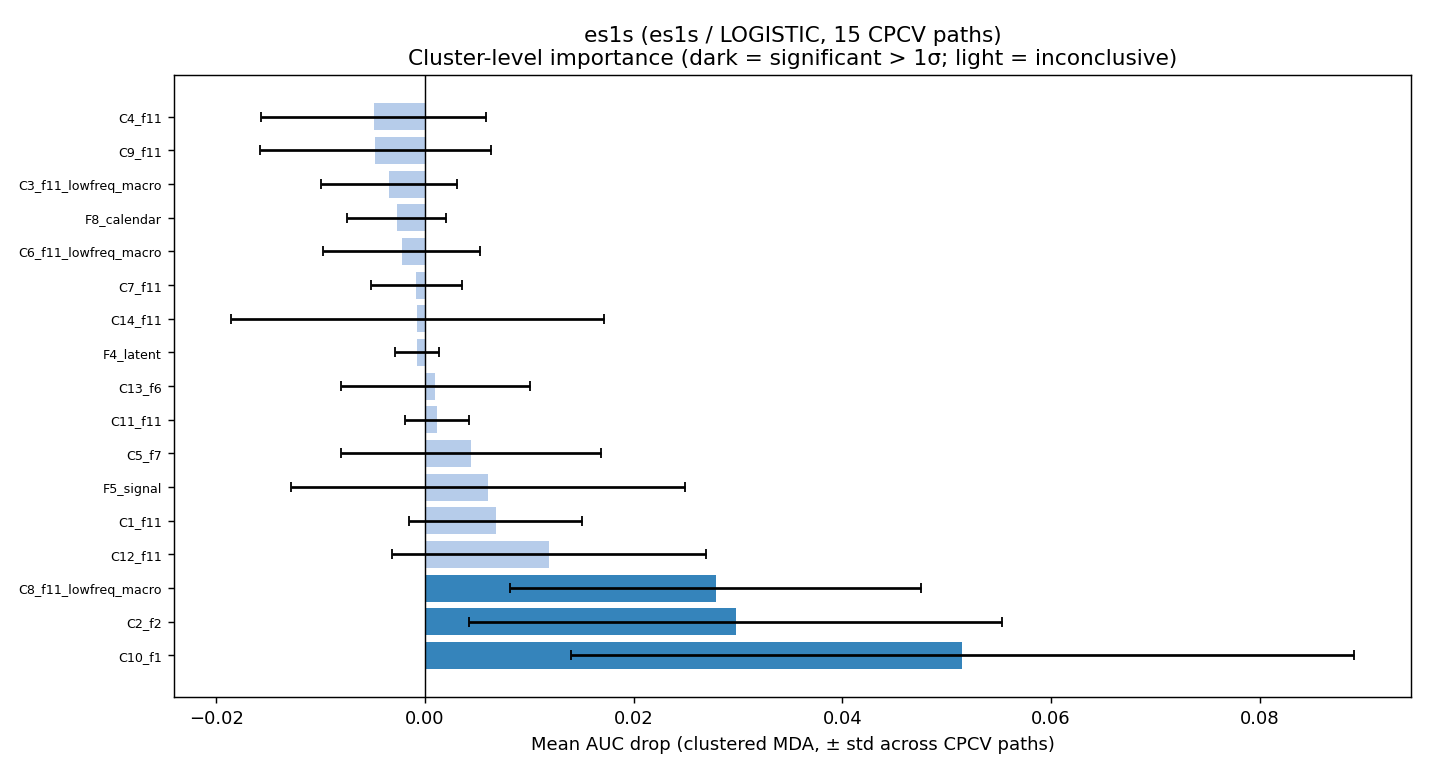

,cluster,mda_mean,mda_rank,coef_sum,coef_rank,significant
0,C10_f1,0.0515,1,0.4316,2,True
1,C2_f2,0.0298,2,0.4784,1,True
2,C8_f11_lowfreq_macro,0.0279,3,0.3030,3,True
3,C12_f11,0.0119,4,0.1750,8,False
4,C1_f11,0.0068,5,0.1943,5,False
5,F5_signal,0.0060,6,0.1887,6,False
6,C5_f7,0.0044,7,0.1417,10,False
7,C11_f11,0.0011,8,0.1353,11,False
8,C13_f6,0.0010,9,0.1194,12,False
9,F4_latent,-0.0007,10,0.0522,17,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-Coef,0.56,True


In [5]:
show_step2('es1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['C10_f1', 'C2_f2', 'C8_f11_lowfreq_macro']


,feature,mean_coef_abs,pc1_loading
0,f1_dist_ma_sigma_10,0.0573,0.276
1,f1_ret_reversal_10,0.0172,-0.237
2,f1_hilo_pos_10,0.0391,0.271
3,f1_mr_score_20,0.0879,-0.236
4,f1_dist_ma_sigma_20,0.0279,0.282
5,f1_hilo_pos_20,0.0255,0.291
6,f1_mr_score_40,0.0197,-0.264
7,f1_dist_ma_sigma_40,0.0005,0.255
8,f1_hilo_pos_40,0.0072,0.267
9,f1_rsi_14,0.0284,0.290


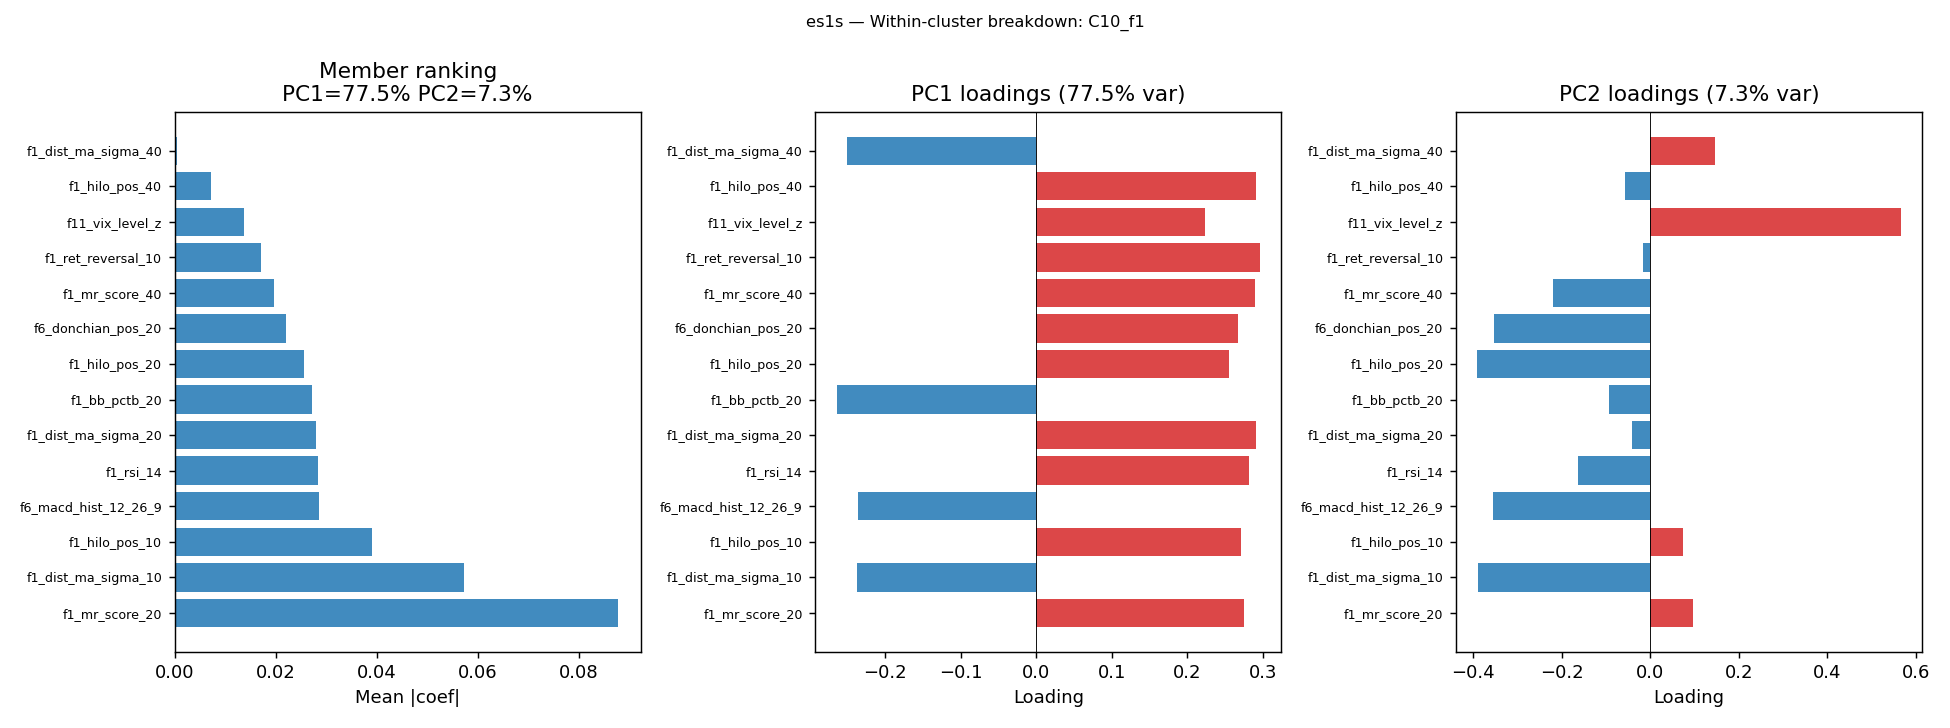

,feature,mean_coef_abs,pc1_loading
0,f1_bb_bandwidth_20,0.0007,0.275
1,f2_vol_10,0.0061,0.278
2,f2_vol_20,0.0040,0.292
3,f2_vol_60,0.0008,0.269
4,f2_vol_pctile_20,0.0439,0.254
5,f2_vol_of_vol_20,0.0035,0.264
6,f2_parkinson_20,0.0015,0.294
7,f2_atr_14,0.0093,0.304
8,f6_ts_momentum_60,0.0572,-0.254
9,f10_hl_range,0.0111,0.246


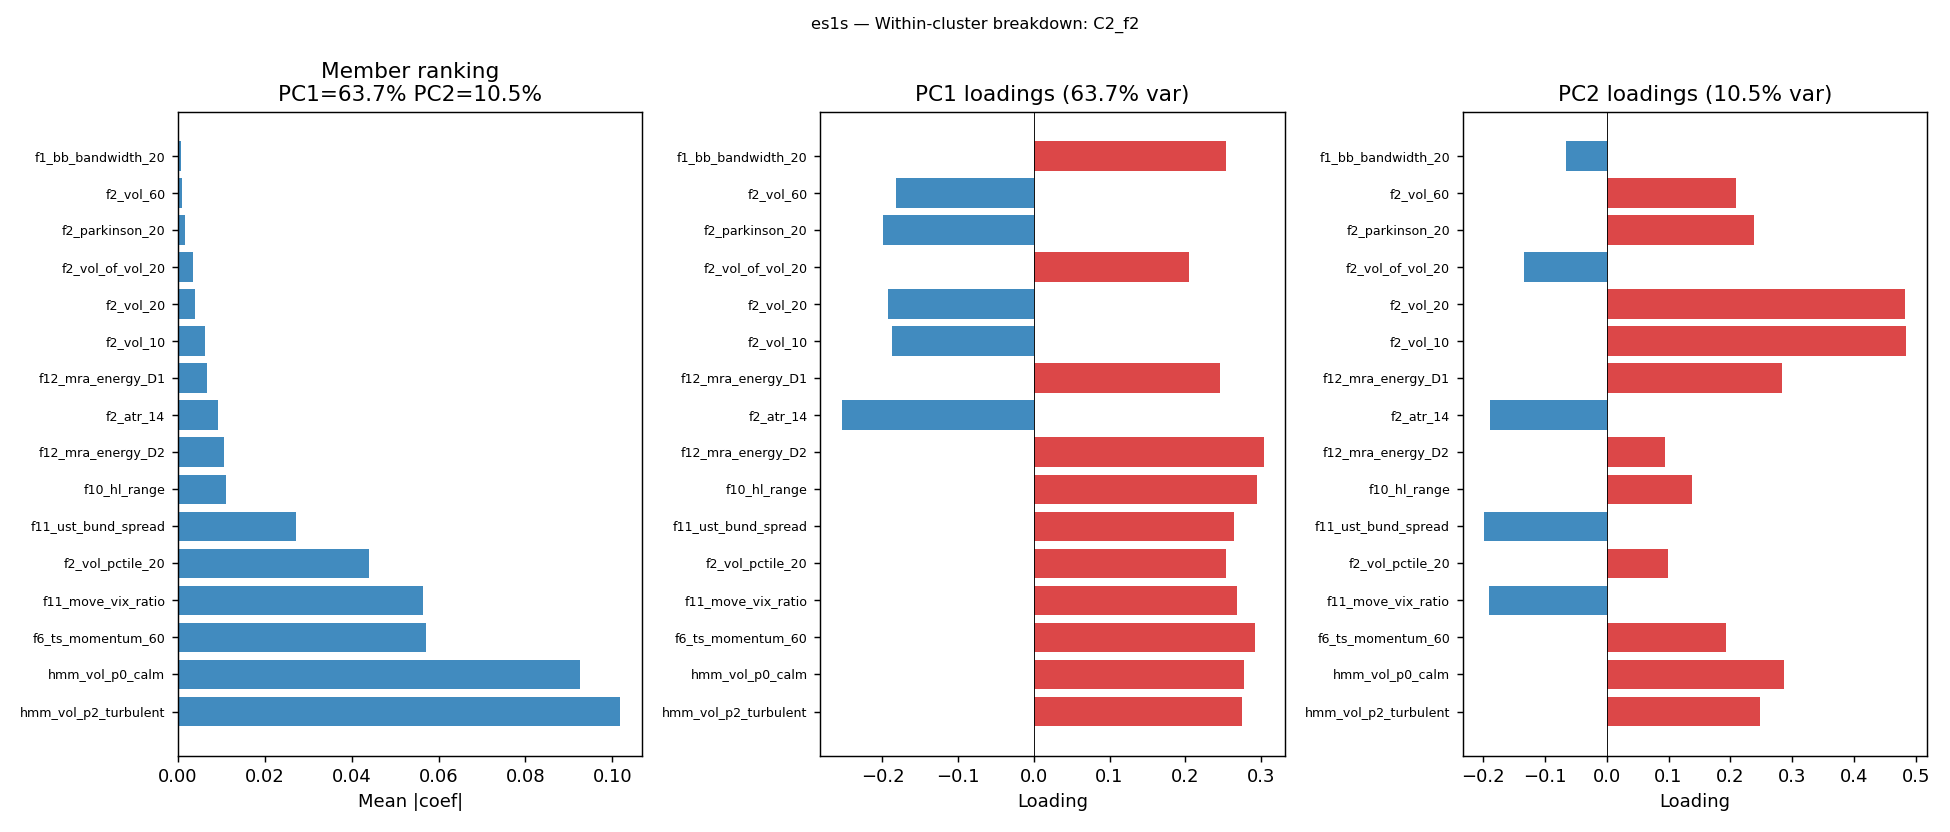

,feature,mean_coef_abs,pc1_loading
0,f11_ust_10y_5d_change,0.2240,0.626
1,f11_bund_10y_5d_change,0.0431,0.596
2,f11_real_yield_10y,0.0240,0.503


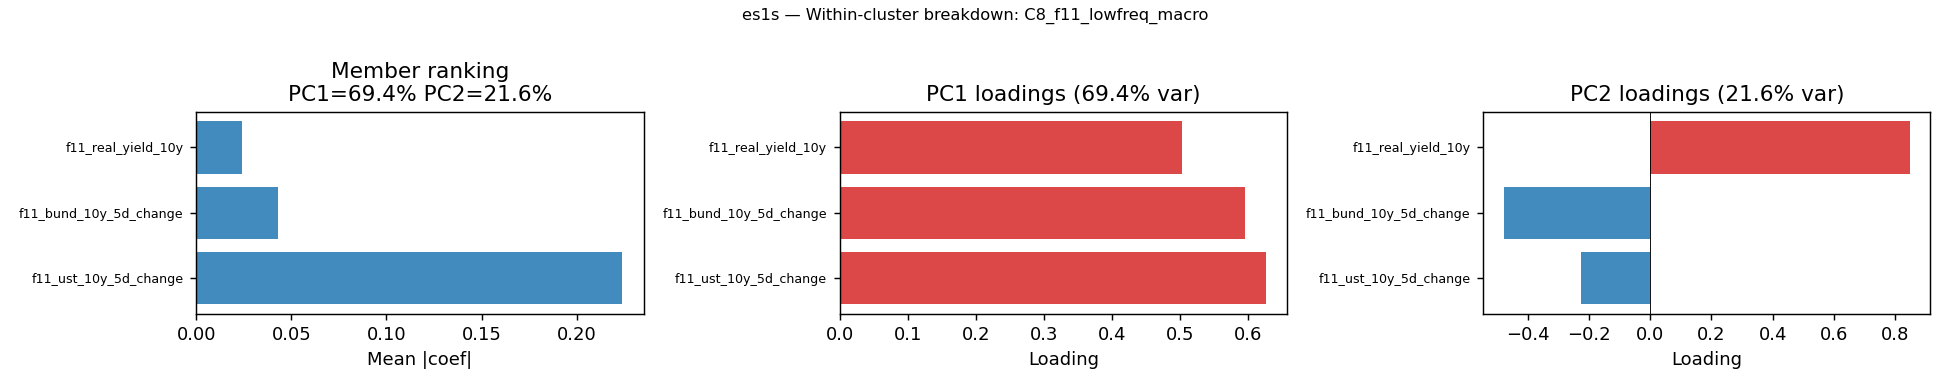

In [6]:
show_step3('es1s')

#### Step 5 · Global feature importance

,feature,coef_abs,coef_signed
0,f11_ust_10y_5d_change,0.2240,-0.2240
1,f11_gasoline_stock_surprise,0.1081,0.1081
2,hmm_vol_p2_turbulent,0.1018,0.1018
3,hmm_vol_p0_calm,0.0925,-0.0925
4,f1_mr_score_20,0.0879,0.0879
5,f7_oi_z_20,0.0763,0.0763
6,f11_hy_oas_5d_change,0.0724,-0.0724
7,f5_signal,0.0618,0.0618
8,f11_vix_5d_change,0.0608,-0.0608
9,f13_path_tortuosity_20d,0.0599,-0.0599


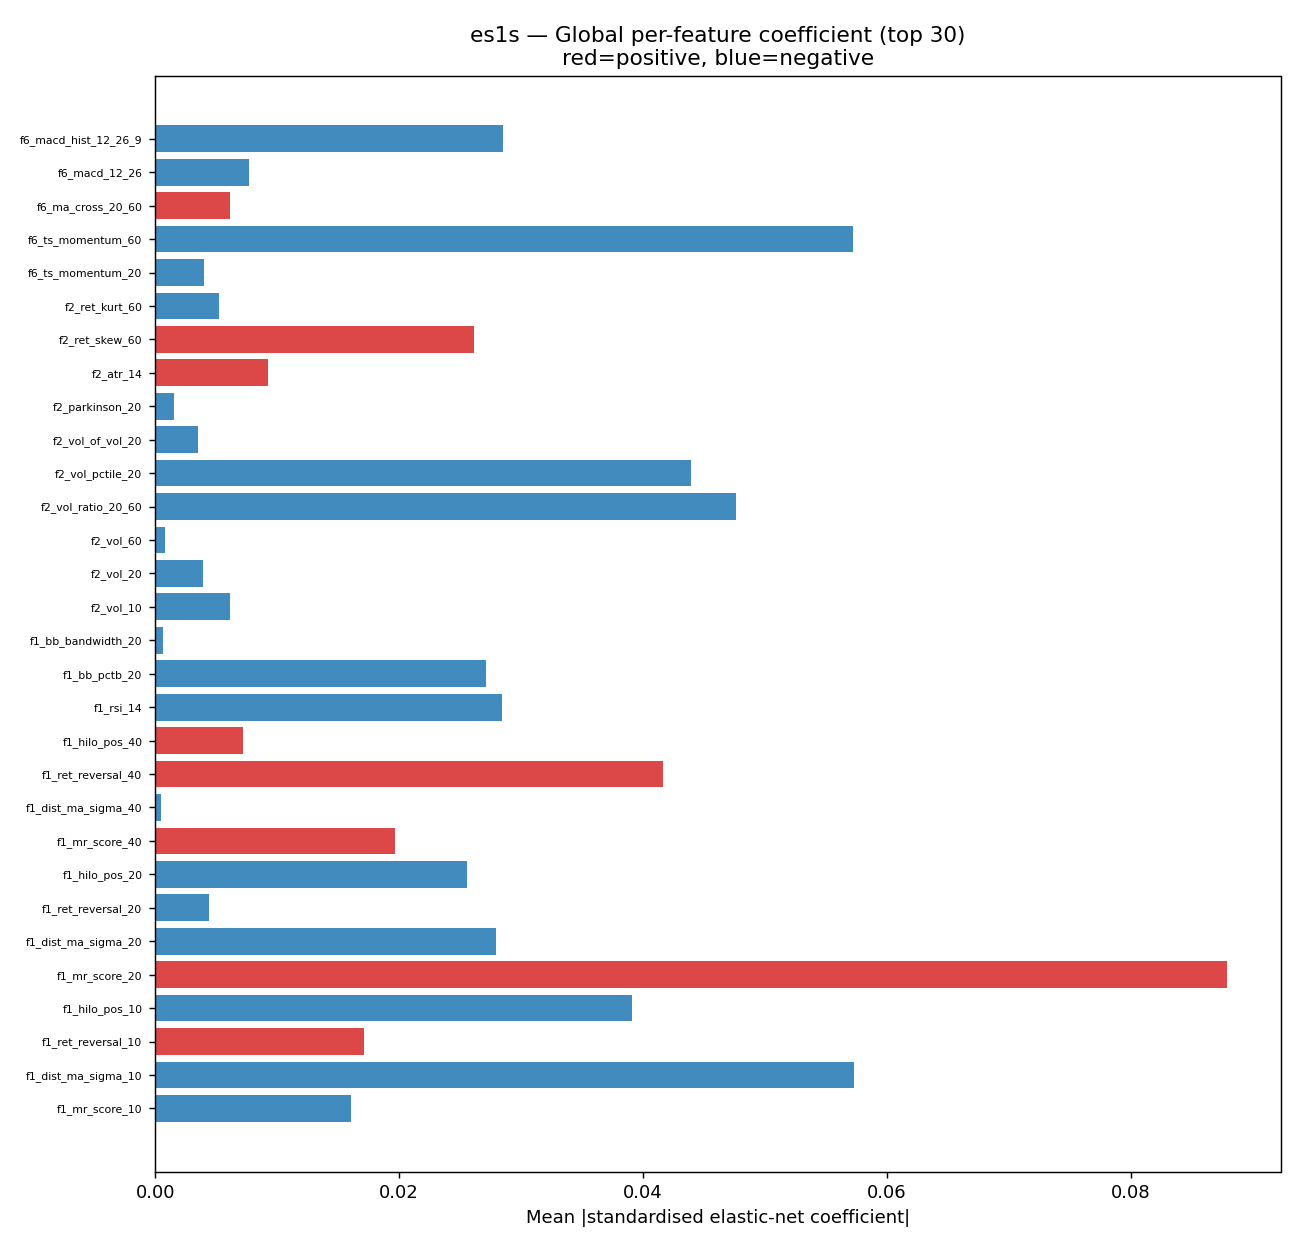

In [7]:
show_step5('es1s')

---
### NQ1S — Steps 1–5

In [8]:
meta = print_header('nq1s')

--- NQ1S | group=nq1s | champion=XGB | family=tree ---
CPCV: 15 paths  AUC 0.5702 ± 0.0328  SIGNAL (lower CI 0.5374)
Significant clusters: C8_f11 (MDA 0.0263 ± 0.0201), C1_f1 (MDA 0.0220 ± 0.0195)


#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
13,C8_f11,9,f11_,78%,0.0263,0.0201,True
6,C1_f1,13,f1_,85%,0.0220,0.0195,True
10,C5_f2,9,f2_,56%,0.0140,0.0234,False
7,C2_f6,5,f6_,40%,0.0105,0.0203,False
8,C3_f6,6,f6_,33%,0.0049,0.0106,False
1,C11_f11,7,f11_,57%,0.0033,0.0151,False
0,C10_f7,2,f7_,100%,0.0029,0.0119,False
16,F5_signal,5,f5_,100%,0.0026,0.0121,False
11,C6_f11,6,f11_,83%,0.0015,0.0069,False
15,F4_latent,4,f4_,100%,0.0013,0.0044,False


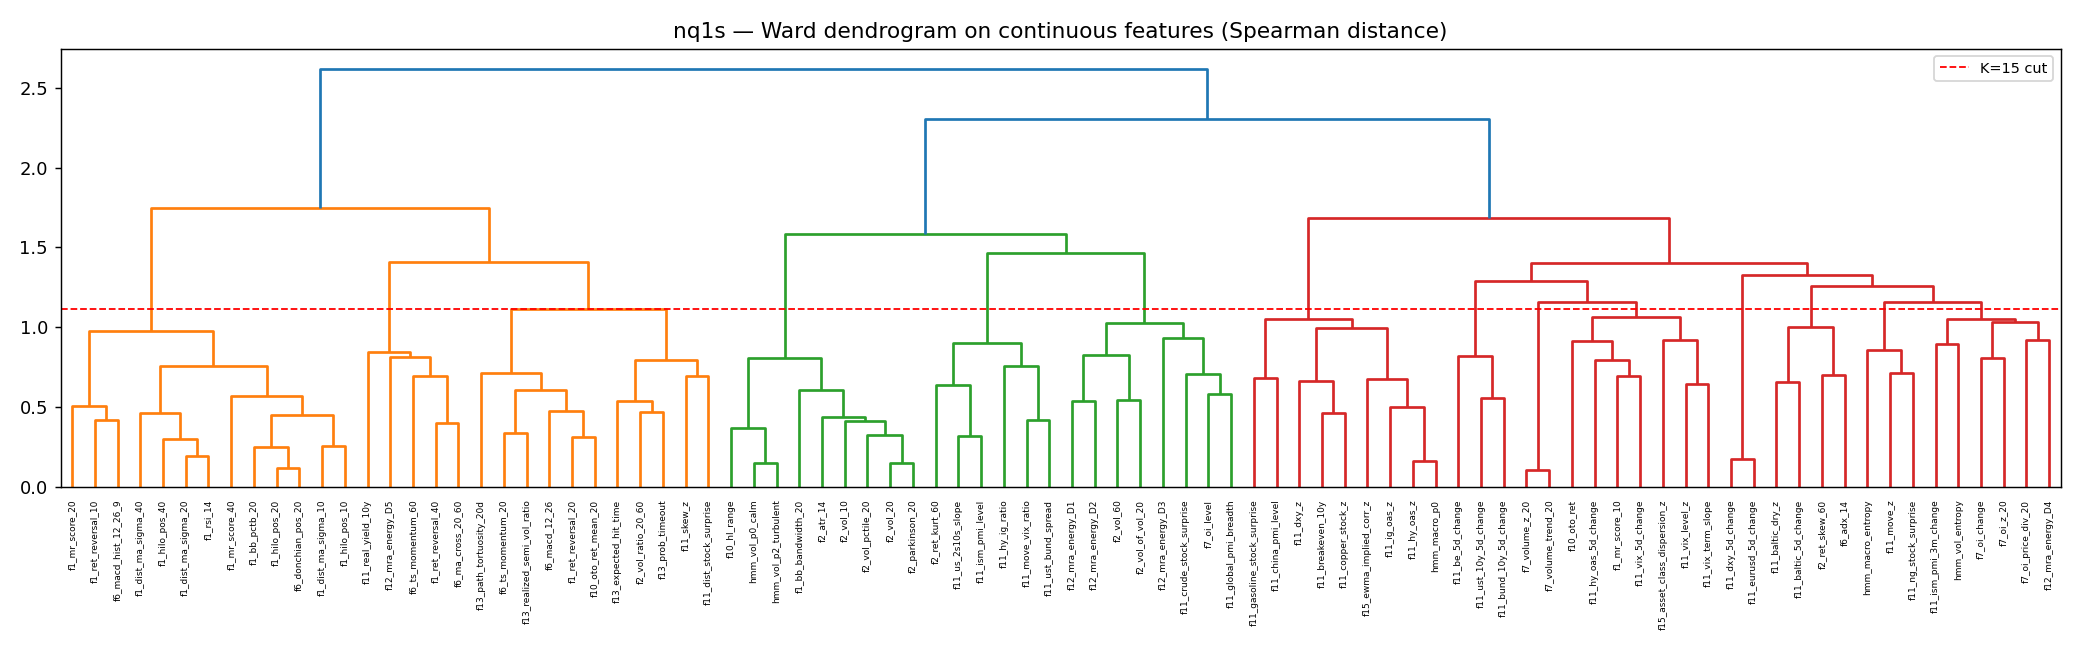

In [9]:
show_step1('nq1s')

#### Step 2 · Cluster-level importance

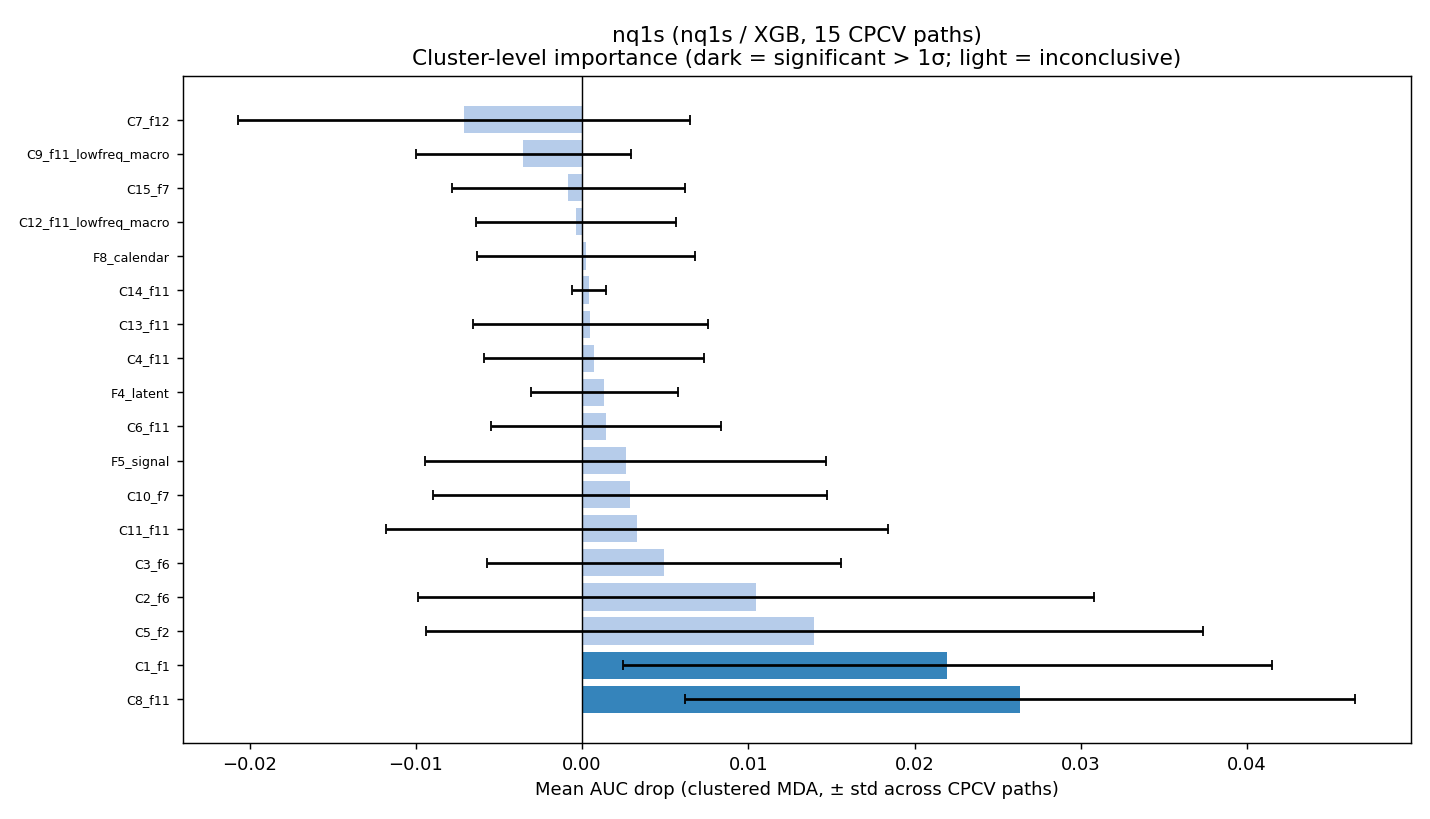

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C8_f11,0.0263,1,0.0925,2,0.0779,1,True
1,C1_f1,0.0220,2,0.1707,1,0.0614,2,True
2,C5_f2,0.0140,3,0.0769,5,0.0399,5,False
3,C2_f6,0.0105,4,0.0694,6,0.0483,3,False
4,C3_f6,0.0049,5,0.0830,4,0.0256,6,False
5,C11_f11,0.0033,6,0.0900,3,0.0435,4,False
6,C10_f7,0.0029,7,0.0283,14,0.0170,9,False
7,F5_signal,0.0026,8,0.0253,15,0.0103,14,False
8,C6_f11,0.0015,9,0.0399,10,0.0114,13,False
9,F4_latent,0.0013,10,0.0354,11,0.0090,15,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.41,True
1,MDA-SHAP,0.52,True
2,MDI-SHAP,0.76,True


In [10]:
show_step2('nq1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['C8_f11', 'C1_f1', 'C5_f2']


,feature,mean_shap_mag,pc1_loading
0,f11_breakeven_10y,0.0127,-0.363
1,f11_hy_oas_z,0.0007,0.397
2,f11_ig_oas_z,0.0011,0.390
3,f11_dxy_z,0.0072,0.246
4,f11_gasoline_stock_surprise,0.0031,-0.153
5,f11_copper_stock_z,0.0501,-0.366
6,f11_china_pmi_level,0.0001,-0.300
7,f15_ewma_implied_corr_z,0.0010,0.346
8,hmm_macro_p0,0.0019,-0.361


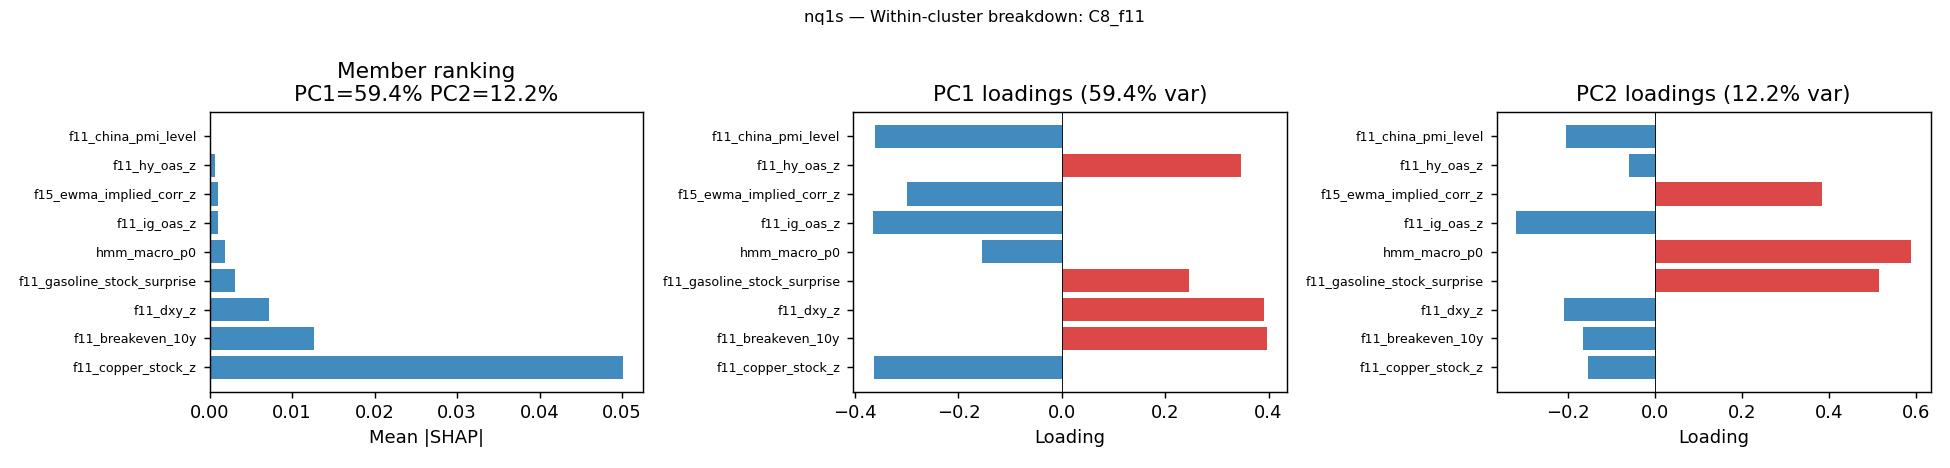

,feature,mean_shap_mag,pc1_loading
0,f1_dist_ma_sigma_10,0.0022,0.283
1,f1_ret_reversal_10,0.0102,-0.263
2,f1_hilo_pos_10,0.0011,0.281
3,f1_mr_score_20,0.0017,-0.234
4,f1_dist_ma_sigma_20,0.0001,0.291
5,f1_hilo_pos_20,0.0043,0.301
6,f1_mr_score_40,0.0020,-0.273
7,f1_dist_ma_sigma_40,0.0048,0.240
8,f1_hilo_pos_40,0.0100,0.273
9,f1_rsi_14,0.0093,0.296


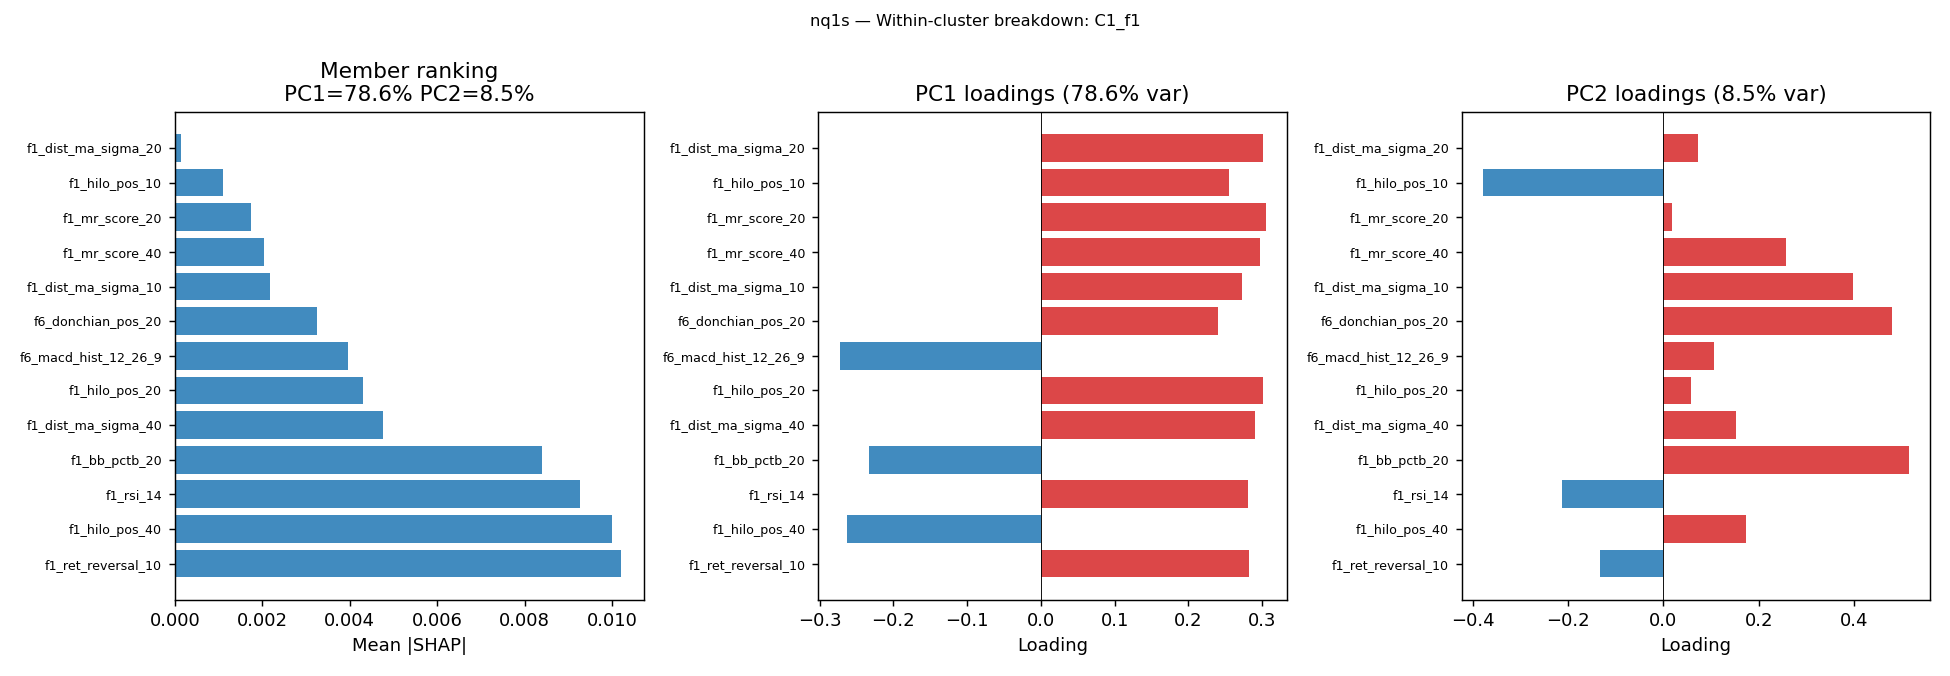

,feature,mean_shap_mag,pc1_loading
0,f1_bb_bandwidth_20,0.0016,0.348
1,f2_vol_10,0.0033,0.358
2,f2_vol_20,0.0004,0.364
3,f2_vol_pctile_20,0.0012,0.316
4,f2_parkinson_20,0.0007,0.363
5,f2_atr_14,0.0012,0.354
6,f10_hl_range,0.0257,0.313
7,hmm_vol_p0_calm,0.0041,-0.255
8,hmm_vol_p2_turbulent,0.0017,0.314


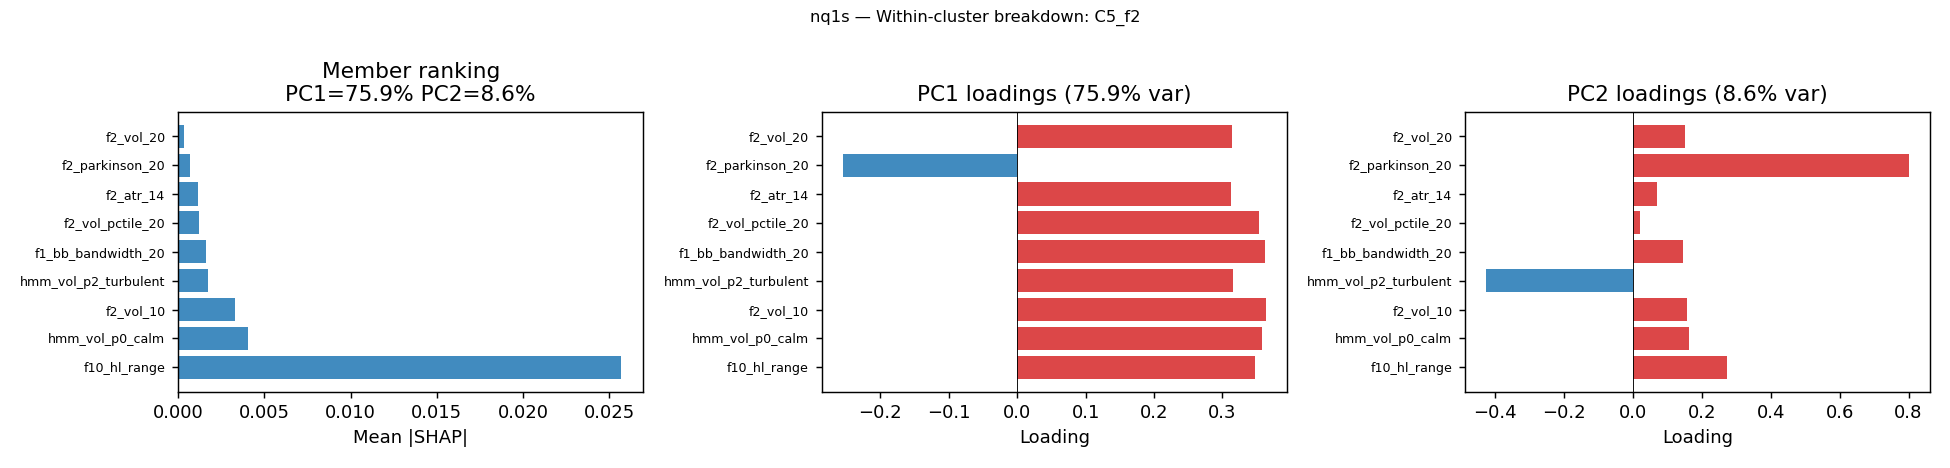

In [11]:
show_step3('nq1s')

#### Step 5 · Global feature importance

,feature,shap_magnitude,shap_signed,mdi
0,f11_copper_stock_z,0.0501,0.0099,0.0244
1,f10_hl_range,0.0257,-0.0116,0.0251
2,f11_real_yield_10y,0.0151,0.0049,0.0114
3,f10_oto_ret,0.0136,0.0002,0.0171
4,f15_asset_class_dispersion_z,0.0134,0.0028,0.0147
5,f1_ret_reversal_40,0.0133,0.0024,0.0192
6,f11_breakeven_10y,0.0127,0.0055,0.0080
7,f7_volume_trend_20,0.0125,-0.0015,0.0170
8,f12_mra_energy_D5,0.0108,-0.0005,0.0164
9,f1_ret_reversal_10,0.0102,-0.0017,0.0178


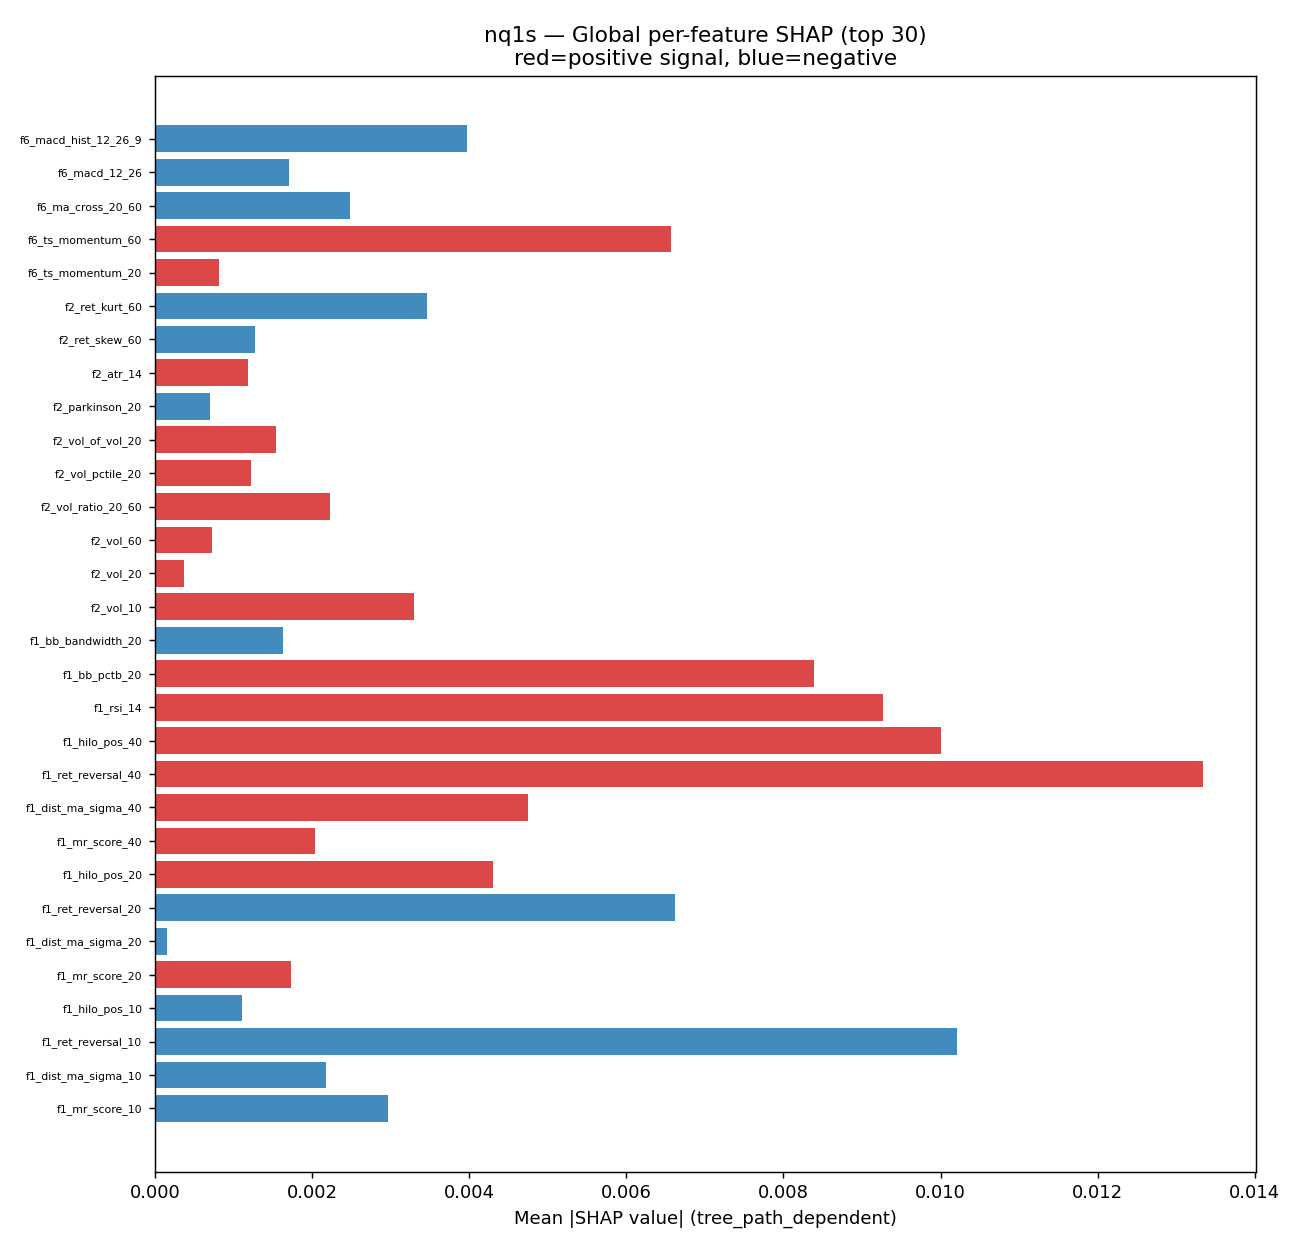

In [12]:
show_step5('nq1s')

---
### FESX1S — Steps 1–5

In [13]:
meta = print_header('fesx1s')

--- FESX1S | group=fesx1s | champion=RF | family=tree ---
CPCV: 15 paths  AUC 0.4964 ± 0.0242  NO SIGNAL (lower CI 0.4722)
Significant clusters: none


#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
7,C2_f1,12,f1_,92%,0.0061,0.0135,False
16,F5_signal,5,f5_,100%,0.0039,0.0060,False
5,C15_f11,6,f11_,33%,0.0030,0.0084,False
12,C7_f7,3,f7_,67%,0.0029,0.0058,False
15,F4_latent,4,f4_,100%,0.0023,0.0058,False
6,C1_f2,16,f2_,44%,0.0017,0.0141,False
10,C5_f11,5,f11_,80%,0.0004,0.0074,False
3,C13_f7,3,f7_,100%,-0.0005,0.0027,False
17,F8_calendar,4,f8_,100%,-0.0011,0.0018,False
0,C10_f12,4,f12_,75%,-0.0011,0.0092,False


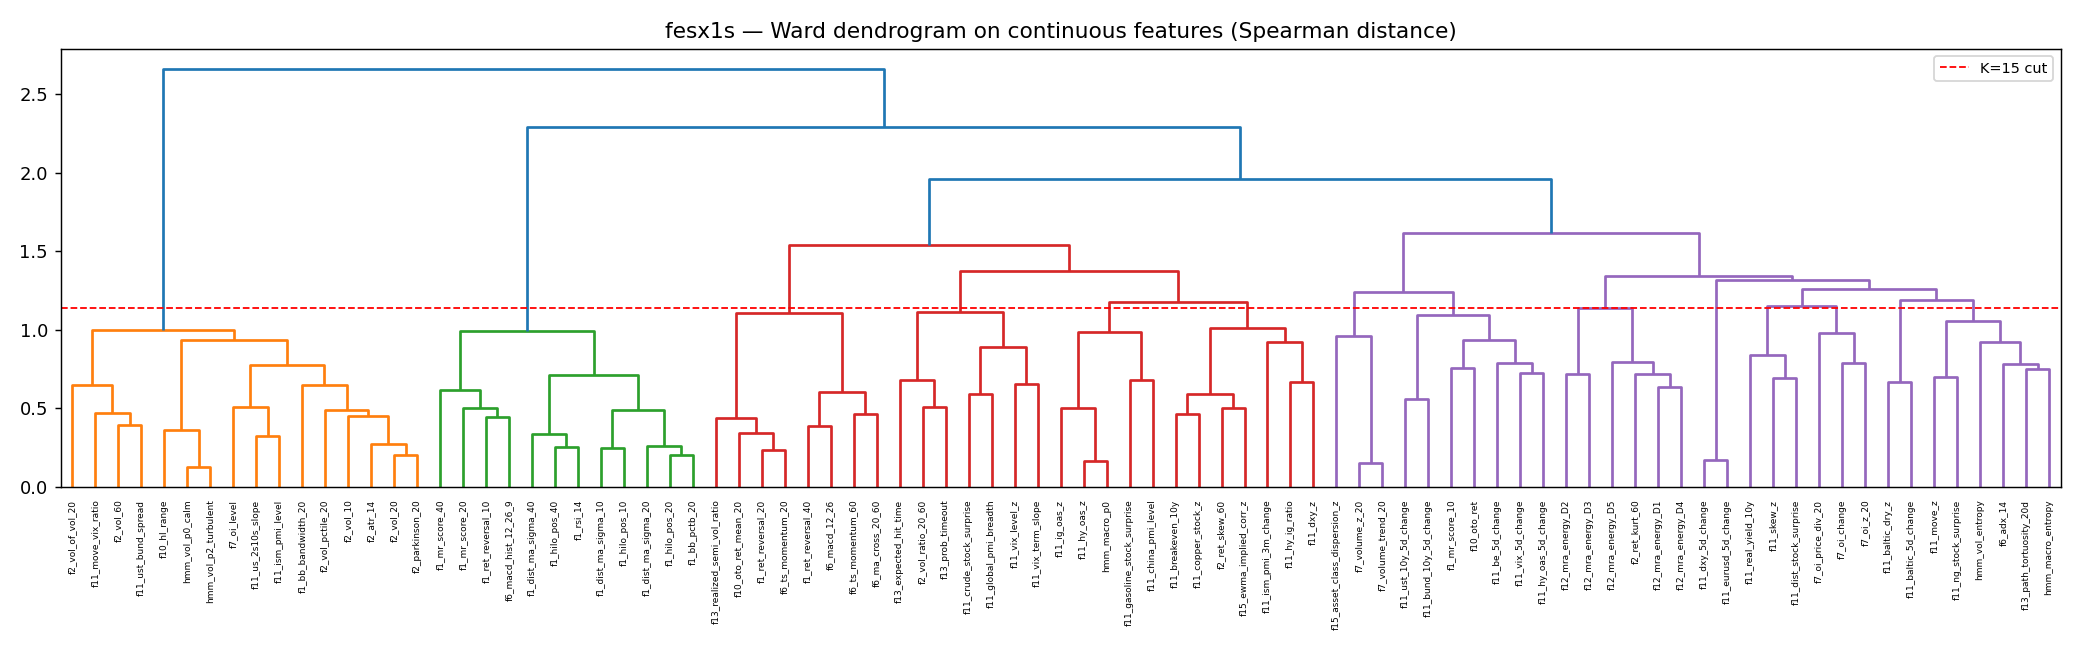

In [14]:
show_step1('fesx1s')

#### Step 2 · Cluster-level importance

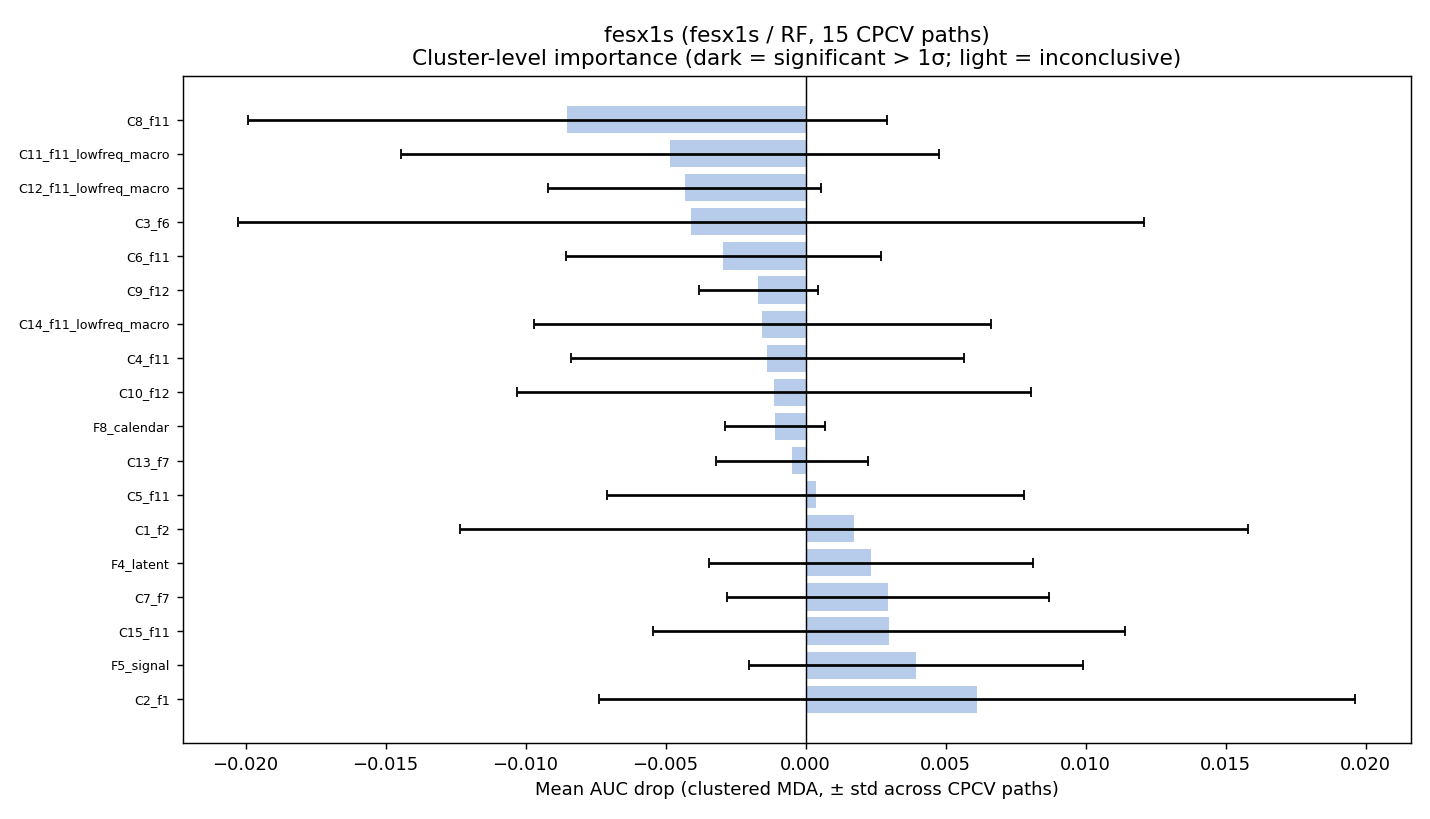

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C2_f1,0.0061,1,0.1359,2,0.0225,2,False
1,F5_signal,0.0039,2,0.0254,14,0.0054,14,False
2,C15_f11,0.0030,3,0.0740,4,0.0112,5,False
3,C7_f7,0.0029,4,0.0477,10,0.0084,8,False
4,F4_latent,0.0023,5,0.0518,8,0.0080,10,False
5,C1_f2,0.0017,6,0.1764,1,0.0292,1,False
6,C5_f11,0.0004,7,0.0393,11,0.0067,11,False
7,C13_f7,-0.0005,8,0.0210,16,0.0028,15,False
8,F8_calendar,-0.0011,9,0.0068,18,0.0013,18,False
9,C10_f12,-0.0011,10,0.0488,9,0.0084,7,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.10,False
1,MDA-SHAP,0.12,False
2,MDI-SHAP,0.92,True


In [15]:
show_step2('fesx1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['C2_f1', 'F5_signal', 'C15_f11']


,feature,mean_shap_mag,pc1_loading
0,f1_dist_ma_sigma_10,0.0024,0.301
1,f1_ret_reversal_10,0.0010,-0.258
2,f1_hilo_pos_10,0.0014,0.290
3,f1_mr_score_20,0.0018,-0.256
4,f1_dist_ma_sigma_20,0.0011,0.314
5,f1_hilo_pos_20,0.0014,0.316
6,f1_mr_score_40,0.0012,-0.278
7,f1_dist_ma_sigma_40,0.0025,0.287
8,f1_hilo_pos_40,0.0046,0.287
9,f1_rsi_14,0.0025,0.309


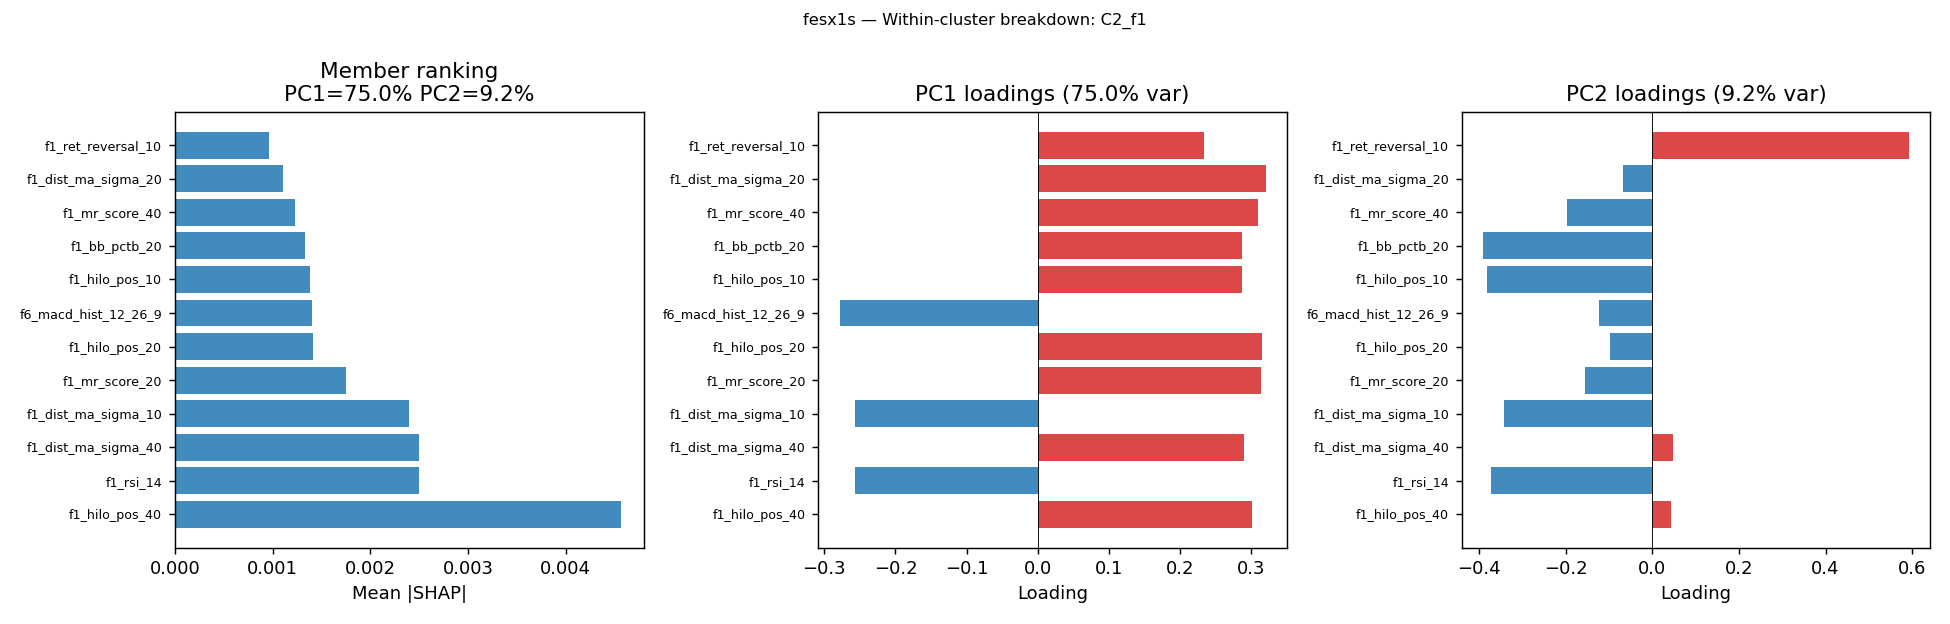

,feature,mean_shap_mag,pc1_loading
0,f5_signal,0.0023,0.495
1,f5_trailing_run_length,0.0019,0.527
2,f5_participation_20,0.0001,0.293
3,f5_long_bias_20,0.0009,0.626
4,f5_sign_agree_mr,0.0002,0.008


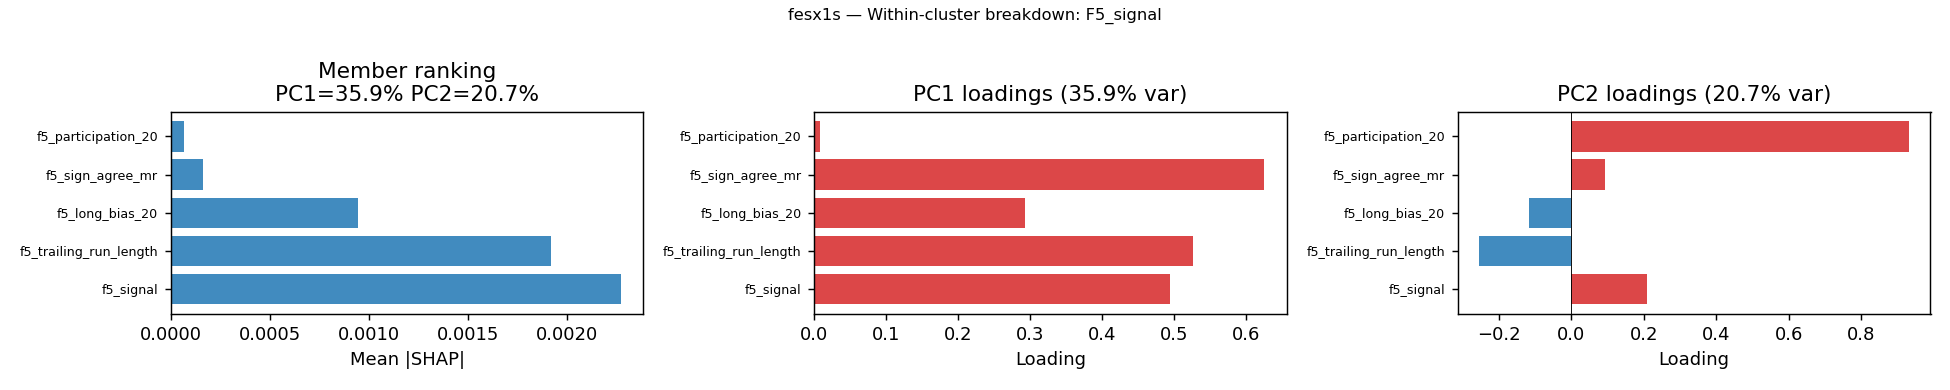

,feature,mean_shap_mag,pc1_loading
0,f6_adx_14,0.0013,0.485
1,f11_move_z,0.0010,0.564
2,f11_ng_stock_surprise,0.0022,-0.549
3,f13_path_tortuosity_20d,0.0021,-0.188
4,hmm_vol_entropy,0.0034,-0.180
5,hmm_macro_entropy,0.0012,-0.279


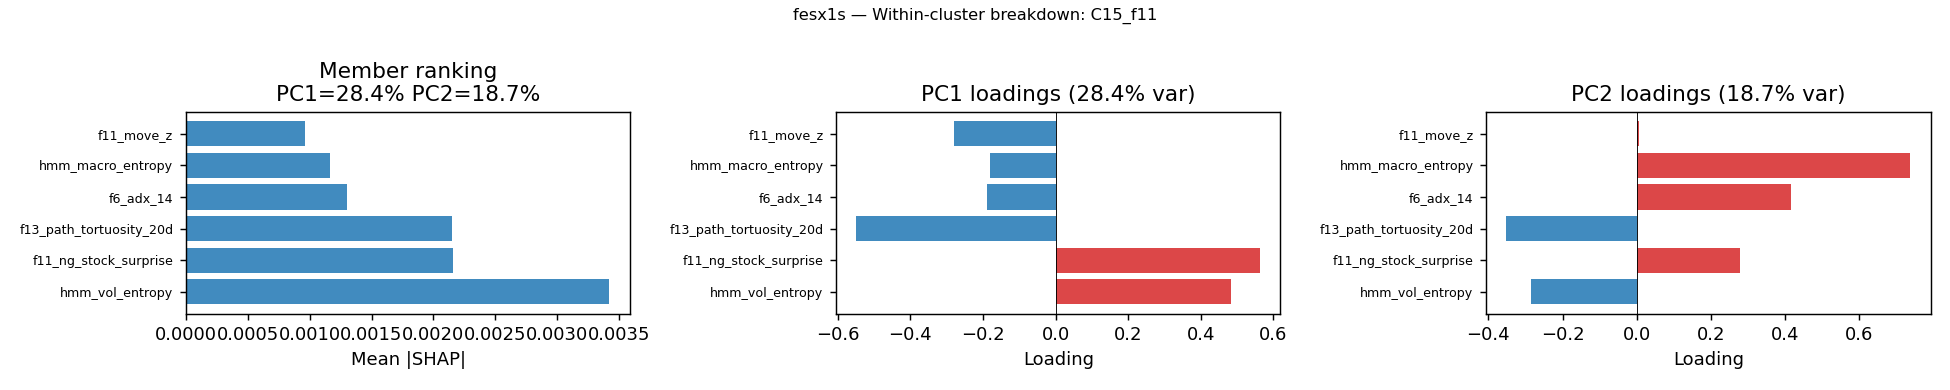

In [16]:
show_step3('fesx1s')

#### Step 5 · Global feature importance

,feature,shap_magnitude,shap_signed,mdi
0,f1_hilo_pos_40,0.0046,0.0005,0.0190
1,f10_hl_range,0.0044,0.0002,0.0208
2,f11_vix_5d_change,0.0043,0.0005,0.0257
3,f4_pc1,0.0036,0.0009,0.0203
4,f1_bb_bandwidth_20,0.0036,0.0010,0.0141
5,f11_baltic_5d_change,0.0035,-0.0005,0.0184
6,hmm_vol_entropy,0.0034,0.0008,0.0230
7,f11_vix_level_z,0.0032,0.0011,0.0181
8,f7_volume_z_20,0.0032,0.0000,0.0167
9,f2_vol_10,0.0030,0.0001,0.0190


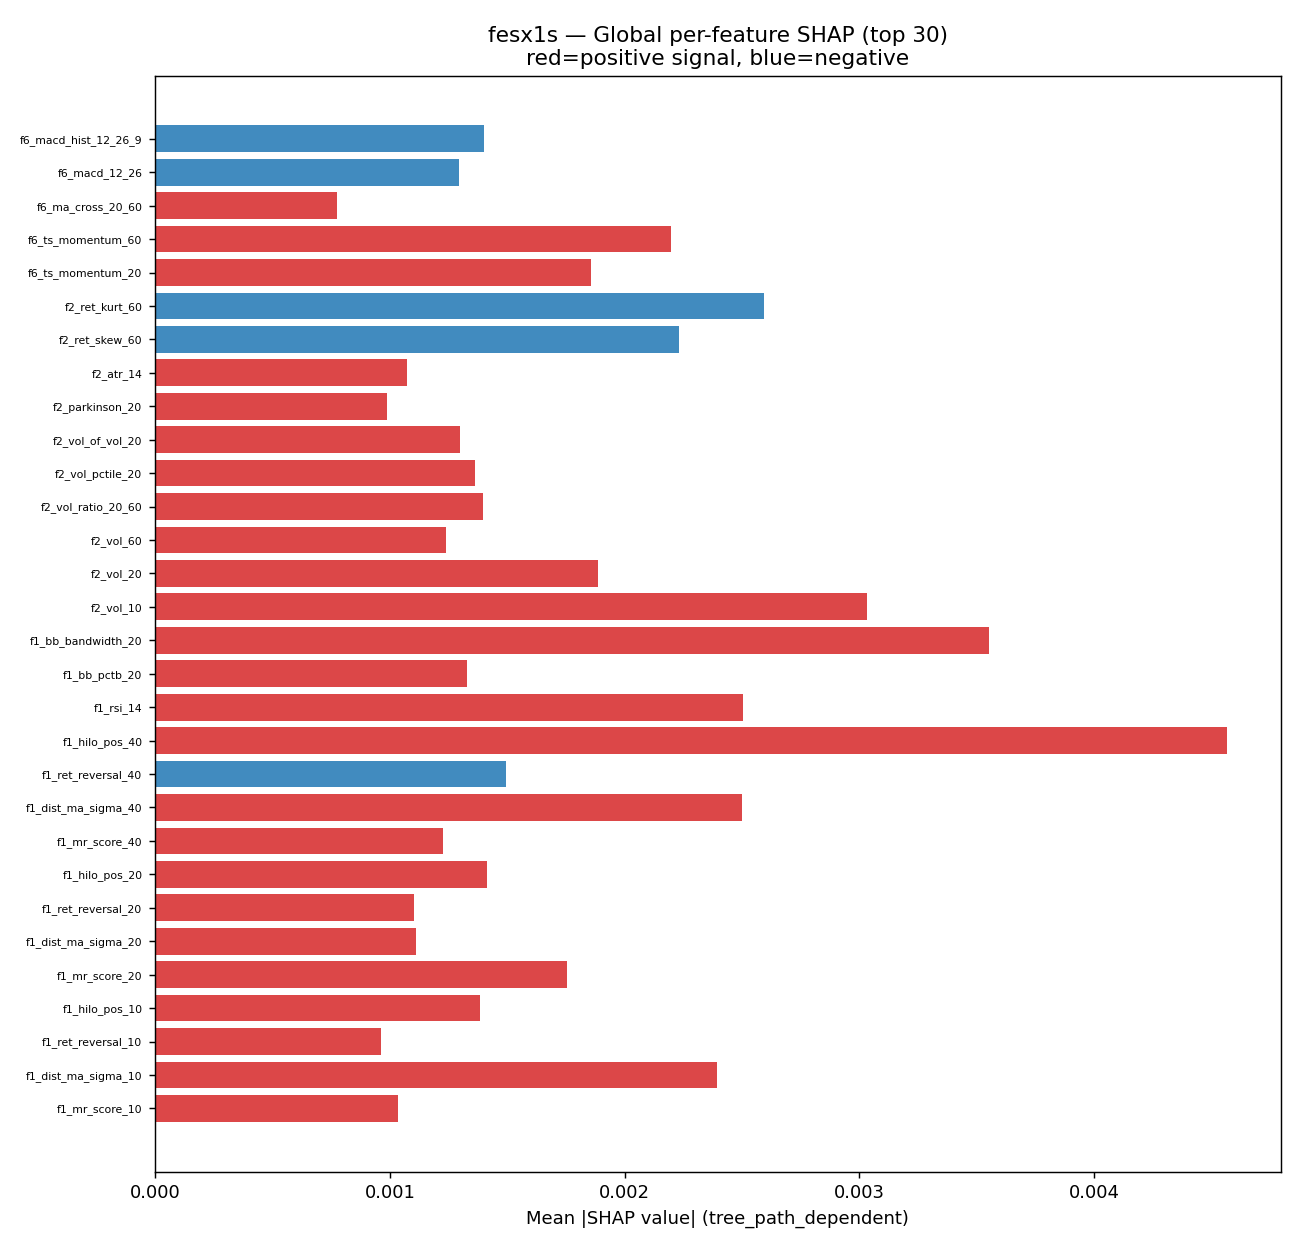

In [17]:
show_step5('fesx1s')

---
## Cross-instrument findings — equity

In [18]:
# Cross-instrument summary — all values from champion_meta + clustered_mda_full
INSTS = ['es1s', 'nq1s', 'fesx1s']

rows = []
for inst in INSTS:
    m   = get_meta(inst)
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    ra  = load(BASE / inst / 'rank_agreement.csv')
    if not m:
        continue
    sig = mda[mda['significant']] if not mda.empty else pd.DataFrame()
    rows.append({
        'inst'          : inst,
        'group'         : m.get('group', '?'),
        'champion'      : m.get('model_type', '?').upper(),
        'family'        : m.get('family', '?'),
        'signal'        : '\u2713' if m.get('signal', False) else '\u2717',
        'AUC'           : f"{m.get('auc_mean', 0):.4f}\u00b1{m.get('auc_std', 0):.4f}",
        'lower_CI'      : f"{m.get('lower_ci', 0):.4f}",
        'n_sig_clusters': int(len(sig)),
        'top_cluster'   : mda.iloc[0]['cluster'] if not mda.empty else '?',
        'top_mda'       : f"{mda.iloc[0]['mean_drop']:.4f}" if not mda.empty else '?',
        '\u03c4_primary' : (f"{ra['kendall_tau'].iloc[0]:.2f}"
                           if not ra.empty else 'n/a'),
    })

summary = pd.DataFrame(rows).set_index('inst')
display(
    summary.style
    .set_caption('Equity champions — cross-instrument summary (all values computed)')
)

print('\nTop-5 MDA per instrument:')
for inst in INSTS:
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    m   = get_meta(inst)
    if mda.empty:
        continue
    tag = '' if m.get('signal', False) else ' (NO SIGNAL)'
    print(f'\n{inst.upper()}{tag}')
    print(mda[['cluster','mean_drop','std_drop','significant']].head(5).to_string(index=False))


,group,champion,family,signal,AUC,lower_CI,n_sig_clusters,top_cluster,top_mda,τ_primary
inst,,,,,,,,,,
es1s,es1s,LOGISTIC,logistic,✓,0.5953±0.0285,0.5668,3,C10_f1,0.0515,0.56
nq1s,nq1s,XGB,tree,✓,0.5702±0.0328,0.5374,2,C8_f11,0.0263,0.41
fesx1s,fesx1s,RF,tree,✗,0.4964±0.0242,0.4722,0,C2_f1,0.0061,0.10



Top-5 MDA per instrument:

ES1S


             cluster  mean_drop  std_drop  significant
              C10_f1   0.051518  0.037564         True
               C2_f2   0.029776  0.025564         True
C8_f11_lowfreq_macro   0.027878  0.019697         True
             C12_f11   0.011900  0.015055        False
              C1_f11   0.006782  0.008300        False

NQ1S
cluster  mean_drop  std_drop  significant
 C8_f11   0.026346  0.020131         True
  C1_f1   0.021968  0.019505         True
  C5_f2   0.013971  0.023378        False
  C2_f6   0.010453  0.020322        False
  C3_f6   0.004924  0.010641        False

FESX1S (NO SIGNAL)
  cluster  mean_drop  std_drop  significant
    C2_f1   0.006117  0.013489        False
F5_signal   0.003938  0.005969        False
  C15_f11   0.002978  0.008419        False
    C7_f7   0.002948  0.005759        False
F4_latent   0.002337  0.005781        False


---
## Consistency assertions

In [19]:
# ── CONSISTENCY ASSERTIONS ─────────────────────────────────────────────────
# (a/b/c) champion_meta matches selection_table
# (d)     Step-3 cluster names == names in clustered_mda_full
# (e)     Step-3 cluster IDs exist in cluster_membership.csv
# (f)     AUC in champion_meta self-consistent (trivially true; verified here for completeness)

INSTS = ['es1s', 'nq1s', 'fesx1s']
errors = []

for inst in INSTS:
    s   = sel.loc[inst]
    m   = get_meta(inst)
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    mem = load(BASE / inst / 'cluster_membership.csv')

    if not m:
        errors.append(f'{inst}: champion_meta.csv missing or empty')
        continue

    # (a/b/c) model type
    meta_model, sel_model = m.get('model_type',''), s['best_model']
    if meta_model != sel_model:
        errors.append(
            f'{inst}: champion_meta model_type={meta_model!r} '
            f'!= selection_table best_model={sel_model!r}'
        )

    # AUC match
    meta_auc = round(float(m.get('auc_mean', -1)), 4)
    sel_auc  = round(float(s['best_auc']), 4)
    if abs(meta_auc - sel_auc) > 0.0001:
        errors.append(
            f'{inst}: champion_meta auc_mean={meta_auc} '
            f'!= selection_table best_auc={sel_auc}'
        )

    if mda.empty:
        errors.append(f'{inst}: clustered_mda_full.csv missing')
        continue

    # (d) Step-3 clusters come from the same MDA table
    step3   = top_n_clusters(inst, n=3)
    mda_set = set(mda['cluster'].tolist())
    for c in step3:
        if c not in mda_set:
            errors.append(f'{inst}: Step-3 cluster {c!r} not in clustered_mda_full.csv')

    # All significant clusters shown (assuming ≤ 3 significant)
    sig_set = set(mda[mda['significant']]['cluster'].tolist())
    shown   = set(step3)
    if len(sig_set) <= 3 and not sig_set.issubset(shown):
        missing = sig_set - shown
        errors.append(f'{inst}: significant clusters {missing} not shown in Step-3')

    # (e) cluster IDs exist in cluster_membership.csv
    if not mem.empty:
        mem_clusters = set(mem['cluster'].unique())
        for c in step3:
            if c not in mem_clusters:
                errors.append(f'{inst}: Step-3 cluster {c!r} not in cluster_membership.csv')

    # (f) AUC fields in champion_meta are internally consistent
    auc_m = m.get('auc_mean', float('nan'))
    lci_m = m.get('lower_ci', float('nan'))
    if not math.isnan(auc_m) and not math.isnan(lci_m) and lci_m > auc_m:
        errors.append(f'{inst}: lower_ci={lci_m} > auc_mean={auc_m} (impossible)')

if errors:
    print('ASSERTION FAILURES:')
    for e in errors:
        print(f'  \u2717 {e}')
    raise AssertionError(f'{len(errors)} assertion(s) failed — see above')
else:
    print(f'\u2713 All assertions passed for {INSTS}')


✓ All assertions passed for ['es1s', 'nq1s', 'fesx1s']
